In [1]:
# Import necessary libraries
import pandas as pd

In [16]:
df = pd.read_csv('../req/MediCare_Readmission_Intelligence.csv')

In [25]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())

# Find duplicate rows
duplicates = df[df.duplicated()]

# Display duplicate rows
print("Duplicate records found:")


Number of duplicate rows: 500
Duplicate records found:


In [26]:
# Total  records
totalRecords = df.shape[0]
print("Total Records: ", df.shape[0])

# Count occurrences of each patient_id
counts = df["patient_id"].value_counts()

# Filter only those with more than 1 occurrence (duplicates)
duplicates = counts[counts > 1]


Total Records:  50500


In [19]:
# Remove duplicates
df_cleaned = df.drop_duplicates()

# Save the cleaned DataFrame back to CSV
df_cleaned.to_csv("../temp/cleaned.csv", index=False)

print("Duplicates removed. Cleaned file saved as 'your_file_cleaned.csv'")

Duplicates removed. Cleaned file saved as 'your_file_cleaned.csv'


In [20]:
# Total  records
cdf = pd.read_csv('../temp/cleaned.csv')

totalRecords = cdf.shape[0]
print("Total Records: ", cdf.shape[0])

Total Records:  50000


In [ ]:
## Data Exploration: Feature Comparison with Readmission Flag

This section visualizes the relationship between each feature and the readmission flag to identify which features contribute most to patient readmission.

```python

```

IndexError: index 21 is out of bounds for axis 0 with size 21

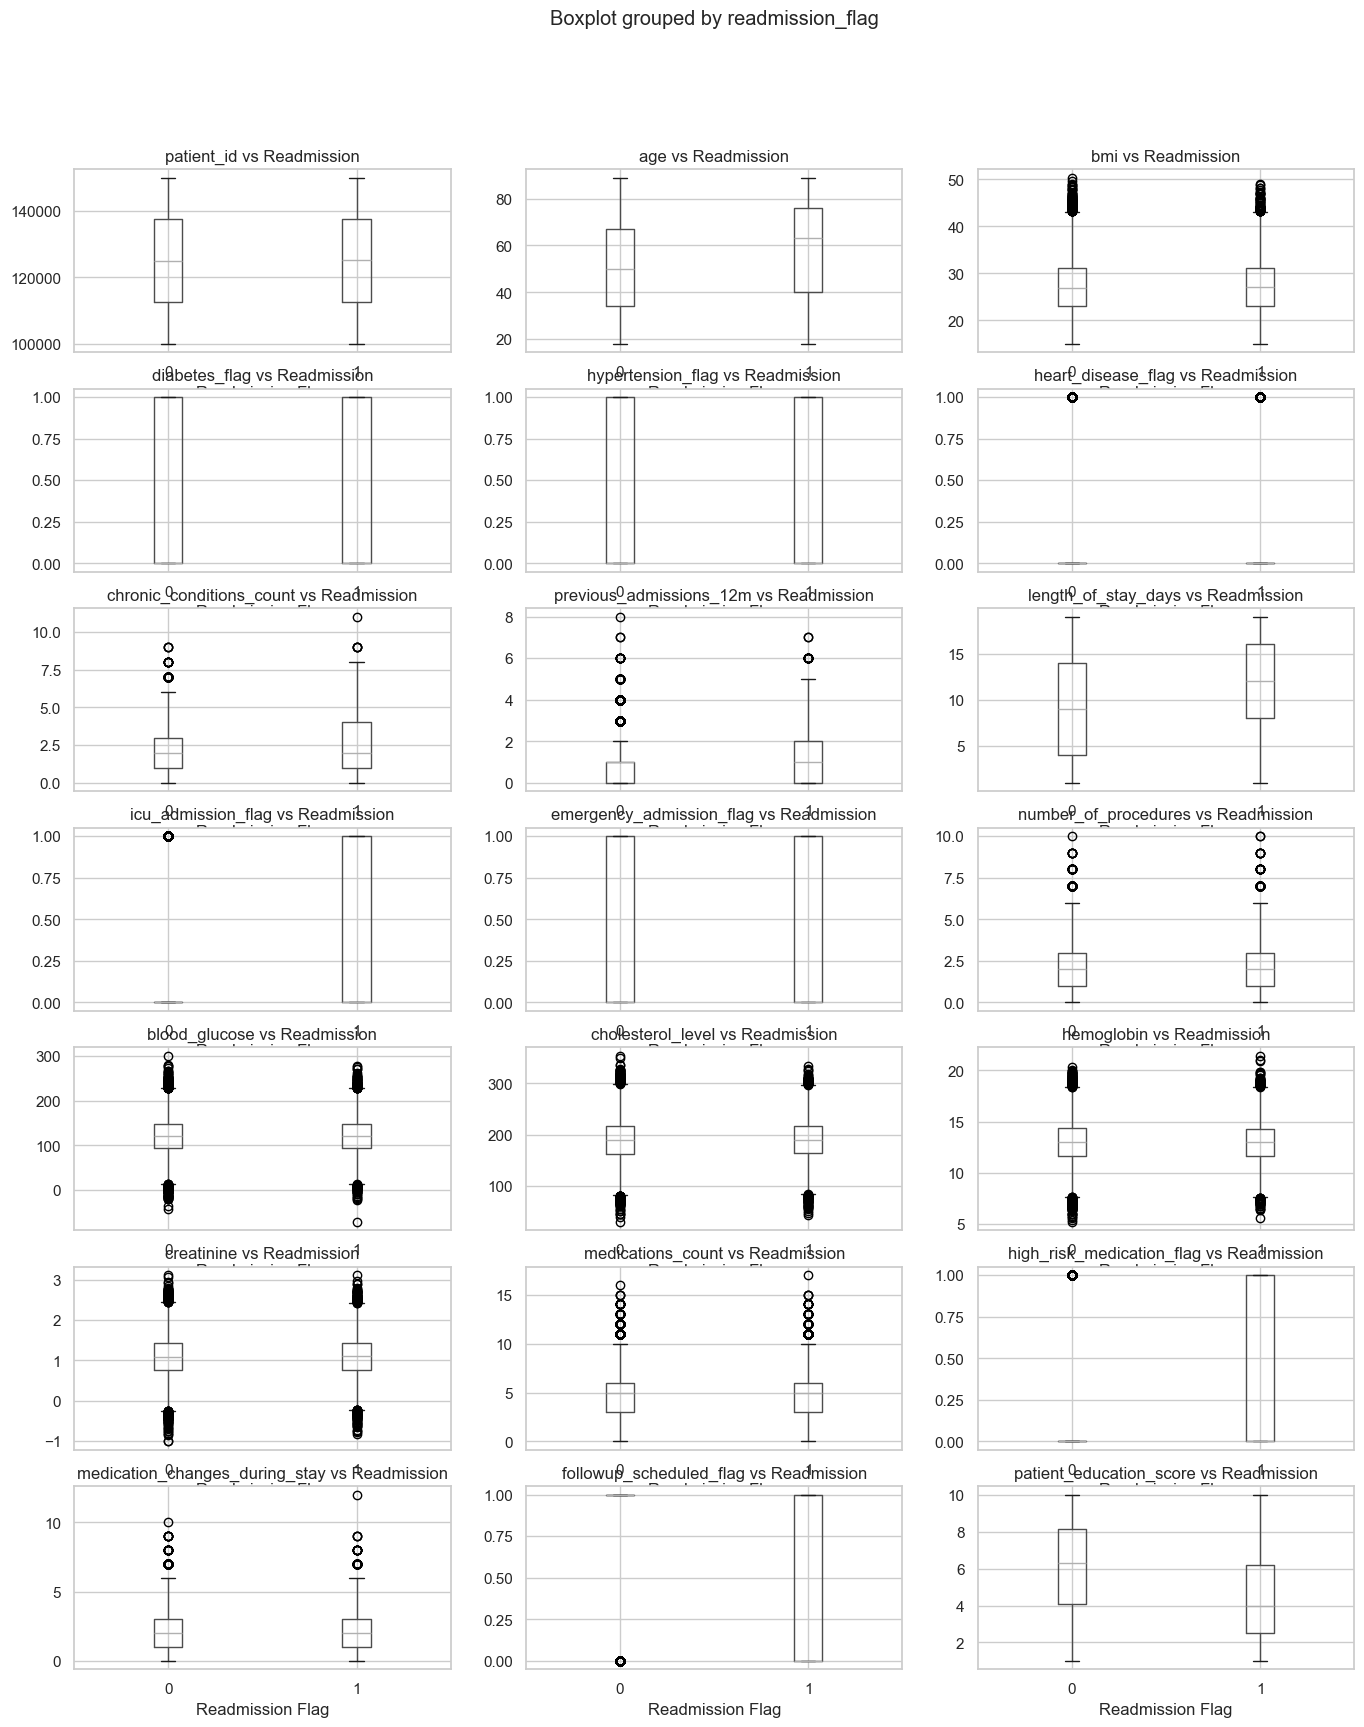

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Separate numeric and categorical columns
numeric_cols = cdf.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('readmission_flag')  # Remove target variable
categorical_cols = cdf.select_dtypes(include=['object']).columns.tolist()

# Create subplots for numeric features
fig, axes = plt.subplots(7, 3, figsize=(16, 20))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if idx >= len(axes):
        break
    cdf.boxplot(column=col, by='readmission_flag', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Readmission')
    axes[idx].set_xlabel('Readmission Flag')

# Hide unused subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Create plots for categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    cross_tab = pd.crosstab(cdf[col], cdf['readmission_flag'], normalize='index') * 100
    cross_tab.plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Readmission (%)')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(['No Readmission', 'Readmission'])

plt.tight_layout()
plt.show()

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1000x800 with 0 Axes>